# Exercises

In [1]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


## Exercise 1 - simulating place cells
---
Use the code we build to simulate place cells in the lesson.

A - Explore what happens when you change the binning in the definition of the firing rate maps (`space_bins`). Make it coarser or broader. 


B - In the spike train simulations, we add some "baseline" noise, not place-related to the firing. Which variable determines the noise level? Try to experiment with that variable and see what happens to the firing rate maps. What is the best approach to firing rate maps when the noise is high.


C - We could use other approaches to firing rate maps: for example make the binning very small (down to 1 cm, which is the resolution of our "video" data, and then applying a gaussian smoother. Scipy has a Gaussian smoother at `scipy.stats.gaussian_kde`. Read the documentation for that function and apply it to the data to define the smoothed firing rate maps. Again, change the noise levels and see how the smoother changes. 

D - When analyzing place fields, two important quantities are the place field center and the place field width. The place field center may be defined in many ways, but one is to compute the "center of mass" of the spikes according to the equation 

$ c_{pf} = \frac{1}{N_{spikes}} \sum_{i} L_i $ 

where the sum on $i$ runs on all spikes emitted by a cell and $L_i$ is the location at which the i-th spike was emitted. Calculate this for each cell. Compare with the "true" place field centers from the simulations (which variables are we talking about?) 


### Code necessary for initializing a simulation

In [2]:
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

The probaility distribution for the place field size has shape

Text(0, 0.5, 'Probability')

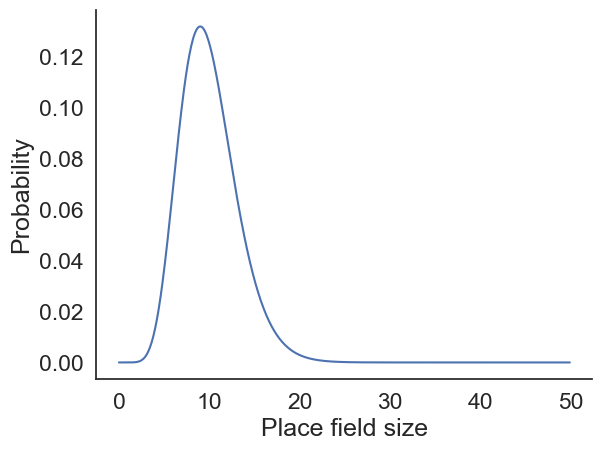

In [3]:
x = np.arange(0., 50., 0.1) # we use a grid with step 0.1
g = scipy.stats.gamma.pdf(x, 10)
plt.plot(x, g)
plt.xlabel('Place field size')
plt.ylabel('Probability')

In [4]:
bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

Text(0, 0.5, 'cell #')

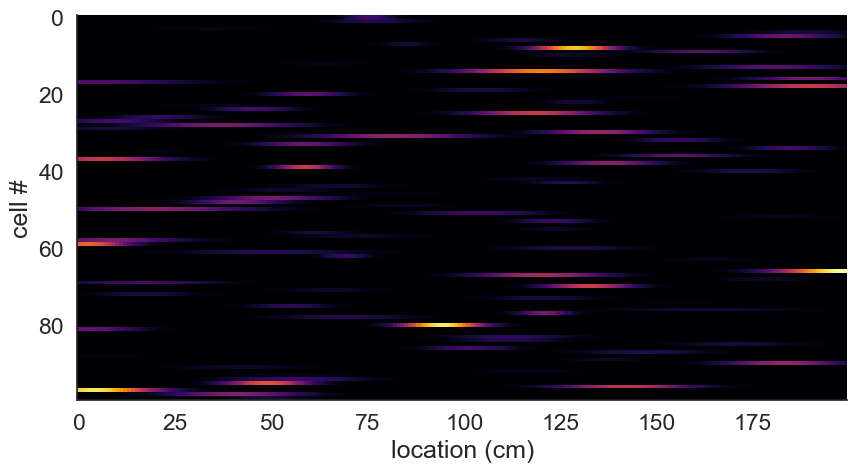

In [5]:
plt.figure(figsize=(10,5))
plt.imshow(true_firing_rate_maps, cmap='inferno')
plt.xlabel('location (cm)')
plt.ylabel('cell #')

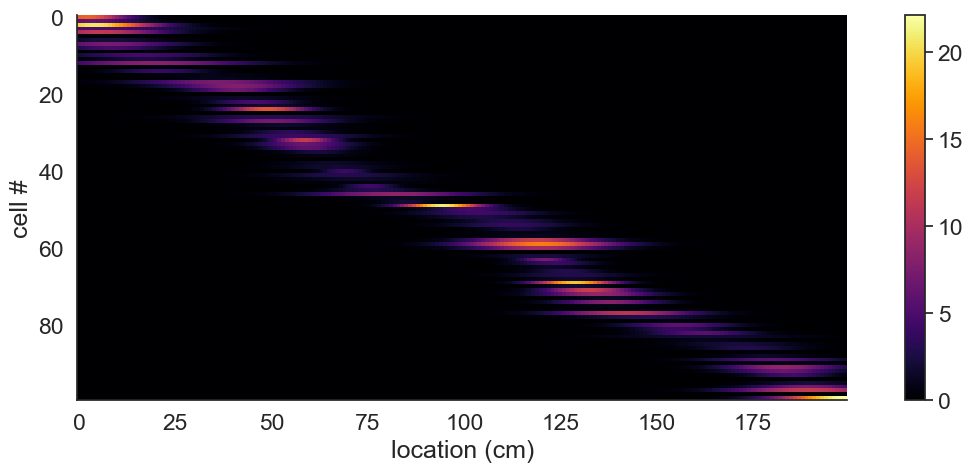

In [6]:
plt.figure(figsize=(15,5))
ix = np.argsort(pf_centers)
plt.imshow(true_firing_rate_maps[ix,:], cmap='inferno')
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

In [7]:
n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0. ## Pads the array with moments (frames) during which the mouse stood still at x = x_start (x=0 in this case)
    run_length = len(bins) * fps / running_speed_a[i]      ## Number of frames in a run, during movement over the track_length assuming a constant speed
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))  ## Number of frames in run is used to define the step increase in x with each frame as a result of the movement speed
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.) ## Pads the array with moments during which the mouse stood still at x= s_stop (x=1 in this case)
    run_length = len(bins) * fps / running_speed_b[i]  ## Same thing as before with run_length only now for the other speed
    run2 = np.linspace(len(bins)-1., 0., int(run_length))   ## Same thing as before but now the reverse of run1, this is the positions for the frames during which the mouse runs back from x=1 to x=0
    x = np.concatenate((x, stop1, run1, stop2, run2)) ## All appended together this gives the x-positions of the mouse at each frame
t = np.arange(len(x))/fps 

Text(0, 0.5, 'position on track (cm)')

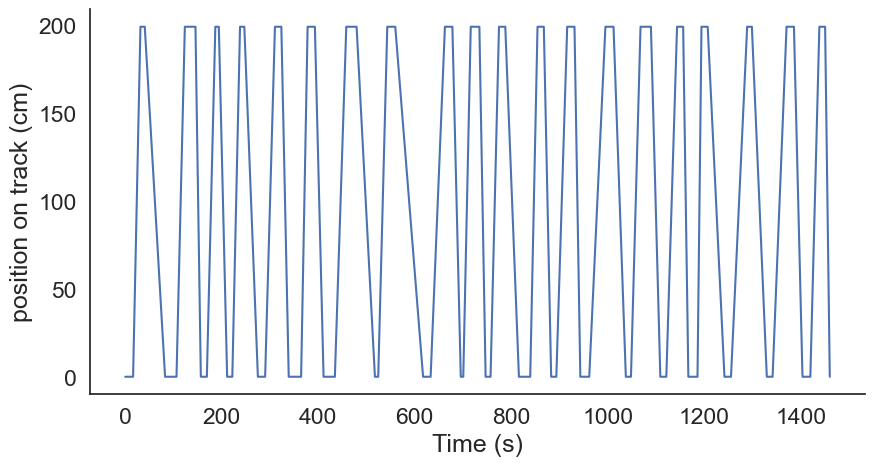

In [8]:
plt.figure(figsize=(10,5))
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('position on track (cm)')

The cell below draws spikes according to an inhomogeneous Poisson process. This is the heart of the simulation. Look at the `for` loop, what is each line of code doing?

In [9]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function then checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

100%|██████████| 100/100 [00:59<00:00,  1.69it/s]


In [10]:
def plot_unit(i):
    plt.figure(figsize=(10,5))
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    plt.xlabel('Time (s)')
    plt.ylabel('position on track (cm)')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0));

interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

A - Explore what happens when you change the binning in the definition of the firing rate maps (`space_bins`). Make it coarser or broader. 


In [ ]:
def plot_hists(binsize):
    spike_positions = [np.interp(s, t, x) for s in spikes]
    space_bins = np.arange(0., 200., binsize)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy
    plt.figure(figsize=(20,5))
    plt.subplot(1,2,1)
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.subplot(1,2,2)
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar();

interact(plot_hists, binsize = widgets.IntSlider(min=1, max=200, value=1))

interactive(children=(IntSlider(value=1, description='binsize', max=200, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_hists(binsize)>

Changing the binsize expectedly broadens the rate distributions in such a way that values that used to be separate are now assigned to the same position. It therefore determines how many different positions (regions in space) are supposedly encoded, and how large receptive fields of the place cells appear. In the rightmost plot you can see that classification of the amount of different poistions depends on roughly tracklength/binsize. It is probably advisable to at least allow for encoding more regions in space than there are cells. The example in the lesson seems to follow this general rule by using binsize = 5 which would lead to 200/5 = 40 possible positions which is twice as many positions than there are cells.

B - In the spike train simulations, we add some "baseline" noise, not place-related to the firing. Which variable determines the noise level? Try to experiment with that variable and see what happens to the firing rate maps. What is the best approach to firing rate maps when the noise is high.

re-running the simulation with a different value for noise firing rate: 
- By reusing the previous function for plotting the histograms it is possible to explore the effects of binsize for each newly defined noise variable

In [12]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = .01 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

interact(plot_hists, binsize = widgets.IntSlider(min=1, max=200, value=1))

100%|██████████| 100/100 [01:02<00:00,  1.61it/s]


interactive(children=(IntSlider(value=1, description='binsize', max=200, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_hists(binsize)>

In [13]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = .1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

interact(plot_hists, binsize = widgets.IntSlider(min=1, max=200, value=1))

100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


interactive(children=(IntSlider(value=1, description='binsize', max=200, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_hists(binsize)>

In [14]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 10. # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

interact(plot_hists, binsize = widgets.IntSlider(min=1, max=200, value=1))

100%|██████████| 100/100 [01:03<00:00,  1.58it/s]


interactive(children=(IntSlider(value=1, description='binsize', max=200, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_hists(binsize)>

The plots above show most clearly what happens in the presence of adding baseline noise and what can be done to mediate the effects: 
- As the noise intensity is raised there is a generally heightened baseline firing rate for all positions for each cell. In the firing rate maps above this is seen in both the color scale's heightened maximum and minimum values and in the appearance of more colored positions for all cells that were previously near black for the same binsize see previous simulations (don't use the slider though as this will have the function redraw the histograms with the noise levels belonging to this run!)
- Moving the slider towards larger binsizes for the above firing rate maps will result in the maps seemingly returning to something similar to the maps drawn for the previous (lower) noise levels. Only with the added issue that fewer positions are now separable from one another and therefore more cells will be classified as encoding for the same spatial position than before.

In [15]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 100. # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

interact(plot_hists, binsize = widgets.IntSlider(min=1, max=200, value=1))

100%|██████████| 100/100 [01:00<00:00,  1.66it/s]


interactive(children=(IntSlider(value=1, description='binsize', max=200, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_hists(binsize)>

As noise increases further the aforementioned effects only magnify and firing rate distributions broaden further making it less obvious for which position a given cell encodes as more overlap between cells encoding for adjacent positions complicates the matter of separating the distributions from one another.

In [16]:
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0))

interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_unit(i)>

The plot above may also be compared with its previously drawn counterpart to confirm the effect of increasing baseline noise level: Each cell almost appears to fire at any time for each position on the track. Whereas for the plot with the lower noise level clear track-position dependent increases in firing rate could be identified from the horizontal bands of dots distributed over the trace

C - We could use other approaches to firing rate maps: for example make the binning very small (down to 1 cm, which is the resolution of our "video" data, and then applying a gaussian smoother. Scipy has a Gaussian smoother at `scipy.stats.gaussian_kde`. Read the documentation for that function and apply it to the data to define the smoothed firing rate maps. Again, change the noise levels and see how the smoother changes. 

In [17]:
def plot_hists_smoothener():
    spike_positions = [np.interp(s, t, x) for s in spikes]

    # occupancy histogram
    space_bins = np.arange(0., 200., 1)
    # Positions at which the KDE is estimated (centered inside the histogram's bins)
    positions = (space_bins[:-1] + space_bins[1:]) / 2
    occupancy = np.histogram(x, space_bins)[0] / fps

    firing_rate_maps = []
    for s in spike_positions:

        s = np.asarray(s).ravel()  

        kde = scipy.stats.gaussian_kde(s)

        smooth_spikes = kde(positions)

        smooth_spikes *= len(s)

        firing_rate = smooth_spikes / occupancy

        firing_rate_maps.append(firing_rate)

    firing_rate_maps = np.vstack(firing_rate_maps)


    plt.figure(figsize=(20,5))
    plt.subplot(1,2,1)
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.subplot(1,2,2)
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, 200, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar();

100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


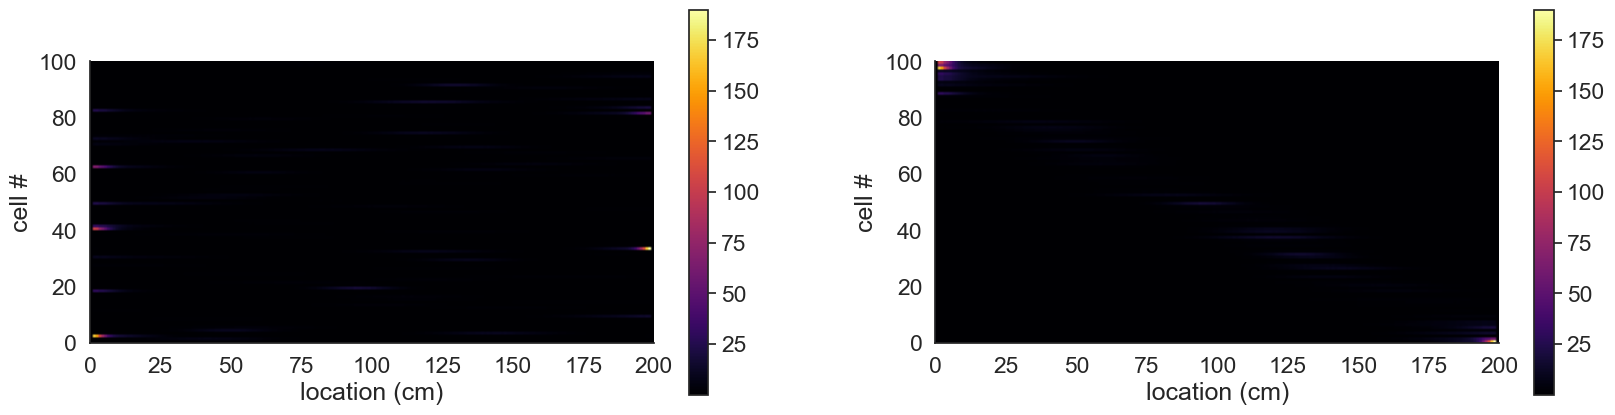

In [18]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i
plot_hists_smoothener()

100%|██████████| 100/100 [01:01<00:00,  1.63it/s]


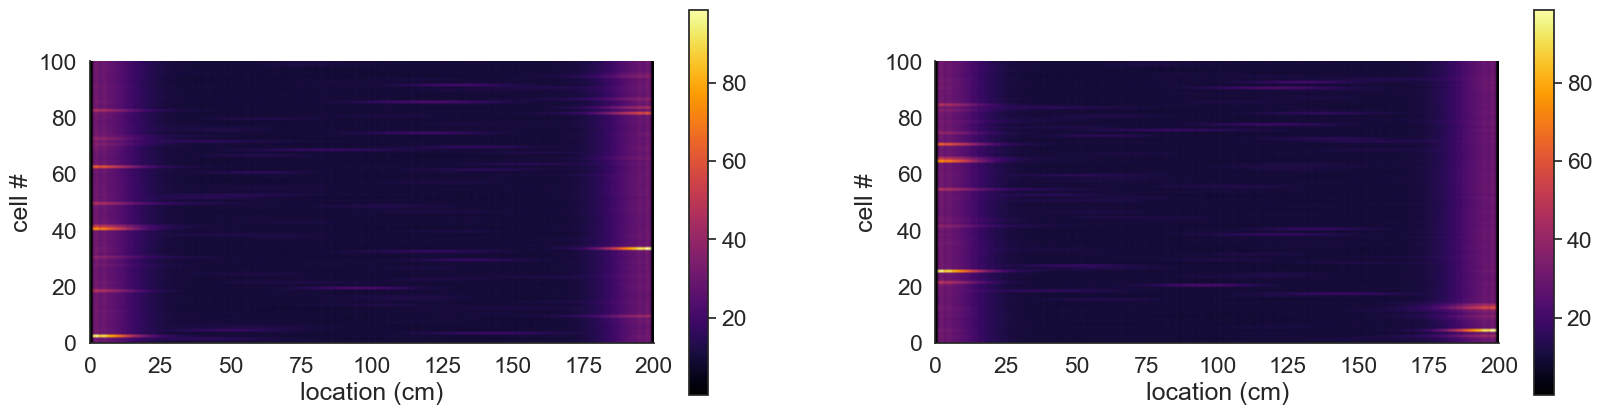

In [19]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 10. # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i
plot_hists_smoothener()

100%|██████████| 100/100 [00:59<00:00,  1.67it/s]


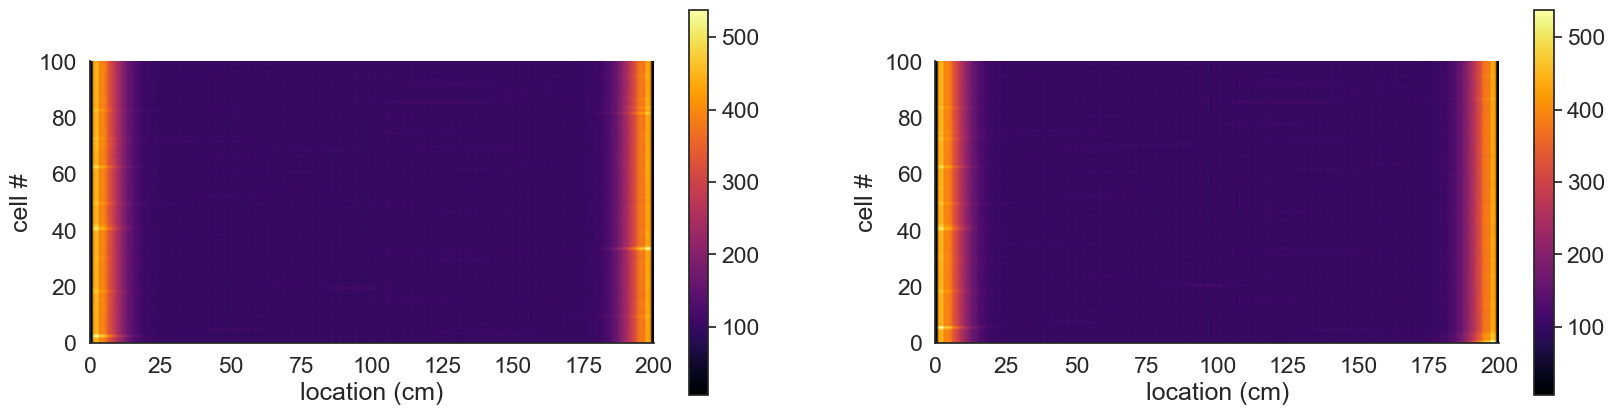

In [20]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 100. # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i
plot_hists_smoothener()

D - When analyzing place fields, two important quantities are the place field center and the place field width. The place field center may be defined in many ways, but one is to compute the "center of mass" of the spikes according to the equation 

$ c_{pf} = \frac{1}{N_{spikes}} \sum_{i} L_i $ 

where the sum on $i$ runs on all spikes emitted by a cell and $L_i$ is the location at which the i-th spike was emitted. Calculate this for each cell. Compare with the "true" place field centers from the simulations (which variables are we talking about?) 

In [21]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

spike_positions = [np.interp(s, t, x) for s in spikes]
centers = np.array([np.mean(s) for s in spike_positions])  ## Since these positions are on a continuous axis it will suffice to take the mean, since no two values will exactly repeat


100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


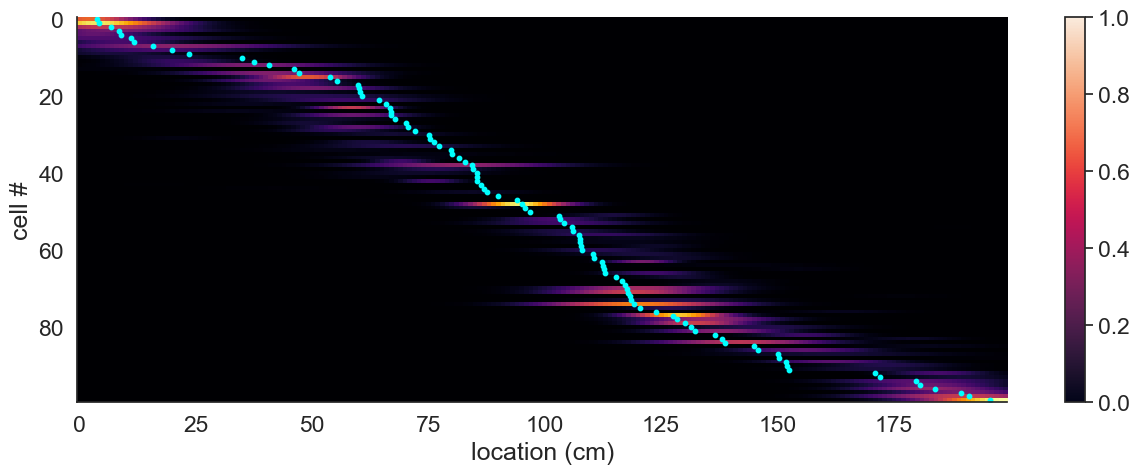

In [22]:
plt.figure(figsize=(15,5))

ix = np.argsort(centers)

plt.imshow(true_firing_rate_maps[ix,:], cmap='inferno', aspect='auto')

plt.scatter(centers[ix], np.arange(len(ix)), c='cyan', s=10)

plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

As can be seen above the centers overlap with the true centers quite well

## Exercise 2 - mutual information
---
A - Implement the mutual information formula discussed in the lesson, and apply it to the place cell data we simulated.

B - Adapt the simulation so that you can systematically vary 1) Peak firing rate, 2) place cell size 3) baseline noise. 
Study how mutual information vary with these parameters. Use both definition of mutual information above, and discuss the differences between them. Make some plots to show how the dependency goes.

$ I = \sum_x \lambda(x) \log_2 \frac{\lambda(x) + \epsilon}{\lambda} p_{occ}(x) $

Where $\epsilon$ is a very small number (e.g. $10^{-15}$) This small number avoids infinities (and NaNs) when $\lambda(x) = 0$.

where $\lambda(x)$ is the firing rate map (as defined above, with some binning precision) $\lambda$ is the average firing rate of the neuron, and $p_{occ}(x)$ is the occupancy as defined above. Information from this formula is expressed in bits per second.

In [23]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)   # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
x_sampling = np.floor(np.interp(t_sampling, t, x)) # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in tqdm(range(n_cells)):   # For each cell i: 
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate  # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)  # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
    sp = np.argwhere(spikes_loc)    # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
    t_sp = t_sampling[sp]   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
    spikes.append(t_sp) # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i


100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


Mutual information: Bits per second definition

In [24]:
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., 200., 5)   # Using binsize = 5 as the default

spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.vstack(spikes_hist).astype(np.float64)
occupancy = np.histogram(x, space_bins)[0] /  fps
firing_rate_maps = spikes_hist / occupancy
occupancy /= np.sum(occupancy)                              # When normalized this produces MI values closer to that of Skagg et. al . I chose to do this even though the lesson states "where p(x) is occupancy as defined above"
mean_firing_rates = np.mean(firing_rate_maps, axis = 1)
eps = 1e-15

MI_cells = []
for cell in range(n_cells):
    MI_cells.append(np.sum(firing_rate_maps[cell]*np.log2((firing_rate_maps[cell] + eps)/mean_firing_rates[cell])*occupancy))
MI_cells


[np.float64(0.45074887757991355),
 np.float64(0.3432717126024374),
 np.float64(0.03724692780334669),
 np.float64(0.08272409798283231),
 np.float64(0.23658437453664194),
 np.float64(1.0733970663974466),
 np.float64(0.24526872998419197),
 np.float64(0.20423343053716048),
 np.float64(3.183808259075024),
 np.float64(1.013574603513688),
 np.float64(0.16982966238956992),
 np.float64(0.033536229539515724),
 np.float64(0.047954207116200895),
 np.float64(1.0482435778373478),
 np.float64(3.357918129534928),
 np.float64(0.07613429512805234),
 np.float64(1.104503855822201),
 np.float64(4.56299853955752),
 np.float64(2.2493193082028995),
 np.float64(0.35477712883733004),
 np.float64(0.7681561496014091),
 np.float64(0.06655864743914025),
 np.float64(0.19151973319055404),
 np.float64(0.1160909092206673),
 np.float64(0.7175426726545868),
 np.float64(2.300931403521698),
 np.float64(0.5303397110774672),
 np.float64(2.650030999785015),
 np.float64(1.337434513160398),
 np.float64(1.5662978867112491),
 np.

Mutual information: bits per spike definition

In [25]:
MI_cells/mean_firing_rates

array([ 1.26372508,  0.86378952,  0.43639492,  0.3330876 ,  0.85722849,
        1.29069218,  0.80238009,  0.74322491,  1.6692526 ,  1.17602827,
        0.65996728,  0.22942566,  0.23974288,  1.19346005,  1.14441249,
        0.36771514,  1.4776589 ,  5.90594908,  1.55183559,  0.88733323,
        1.27004913,  0.28058473,  0.77260446,  0.50953709,  1.29245775,
        1.29420043,  0.97855382,  4.82043156,  0.90563947,  3.99297487,
        1.28309466,  0.95950289,  0.96256271,  1.27829549,  1.29393271,
        0.56894403,  1.10123295,  8.20929232,  1.33454808,  1.56102999,
        0.88358553,  0.29826863,  0.54207346,  1.10772964,  0.62813207,
        0.61859732,  0.25096057,  1.1497925 ,  1.28210856,  0.51216619,
        2.08619559,  0.92648156,  0.40370917,  1.18250288,  0.2323788 ,
        0.54190273,  1.03365009,  0.5727867 ,  6.12572211, 15.90043045,
        0.77177077,  0.64925135,  1.16169408,  0.53115964,  0.24940004,
        0.41115584,  1.86061059,  1.13947432,  0.79924462,  2.42

B - Adapt the simulation so that you can systematically vary 1) Peak firing rate, 2) place cell size 3) baseline noise. 
Study how mutual information vary with these parameters. Use both definition of mutual information above, and discuss the differences between them. Make some plots to show how the dependency goes.

In [29]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd


# DEFINE GLOBAL PARAMETERS

track_length = 200
average_firing_rate = 5
n_cells = 100

# fixed "ground truth" properties of cells
pf_centers = np.random.rand(n_cells) * track_length
base_pf_size = np.random.gamma(10, size=n_cells)
pf_rate_base = np.random.exponential(scale=average_firing_rate, size=n_cells)

# CREATE TRUE ENVIRONMENT + TUNING CURVES

def init_reality(pf_centers,
                 pf_rate_base,
                 pf_gain,
                 base_pf_size,
                 pf_size_scale,
                 n_cells=100):

    # manipulate place field width + firing rate
    pf_size = pf_size_scale * base_pf_size
    pf_rate = pf_gain * pf_rate_base

    # TRUE FIRING RATE MAPS

    bins = np.arange(0., 200.)
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))

    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

    # ANIMAL TRAJECTORY

    n_runs = 20
    fps = 30
    running_speed_a = np.random.chisquare(10, size=n_runs)
    running_speed_b = np.random.chisquare(10, size=n_runs)
    stopping_time_a = np.random.chisquare(15, size=n_runs)
    stopping_time_b = np.random.chisquare(15, size=n_runs)

    x = np.array([])
    for i in range(n_runs):
        stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0. ## Pads the array with moments (frames) during which the mouse stood still at x = x_start (x=0 in this case)
        run_length = len(bins) * fps / running_speed_a[i]      ## Number of frames in a run, during movement over the track_length assuming a constant speed
        run1 = np.linspace(0., float(len(bins)-1), int(run_length))  ## Number of frames in run is used to define the step increase in x with each frame as a result of the movement speed
        stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.) ## Pads the array with moments during which the mouse stood still at x= s_stop (x=1 in this case)
        run_length = len(bins) * fps / running_speed_b[i]  ## Same thing as before with run_length only now for the other speed
        run2 = np.linspace(len(bins)-1., 0., int(run_length))   ## Same thing as before but now the reverse of run1, this is the positions for the frames during which the mouse runs back from x=1 to x=0
        x = np.concatenate((x, stop1, run1, stop2, run2)) ## All appended together this gives the x-positions of the mouse at each frame
    t = np.arange(len(x))/fps 

    return true_firing_rate_maps, x, t, fps

# SIMULATE SPIKES

def sim_experiment(noise_firing_rate,
                   true_firing_rate_maps,
                   x,
                   t,
                   fps):

    sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)                                        # The modified time axis, adjusted for the sampling rate of? (probably how often we draw an outcome from the Poisson distribution)
    x_sampling = np.floor(np.interp(t_sampling, t, x))                                          # Interpolated version of our x-axis, giving additional values based on when we sample and a linear interpolation.
    spikes = []

    for i in tqdm(range(n_cells)):   # For each cell i: 
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate    # This samples the firing rate distribution of cell i at each position of the interpolated (sampled) x-axis + noise. So it returns a predicted firing rate for each moment in time (because the x-axis is a sequence of x-positions at each time moments)
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)                                 # The predicted firing rates at a given x-position (and thus moment in time) are then divided by the sampling rate to give an expected number of spikes at each moment in the sampled time
        sp = np.argwhere(spikes_loc)                                                            # this function than checks all the moments for which a spike was drawn from the poisson process by checking which indices contain a non-zero value (and indices correspond to moments in time)
        t_sp = t_sampling[sp]                                                                   # These moments in time are than passed to t_sampling to obtain spike times for cell_i (why isn't this already in sp?)
        spikes.append(t_sp)                                                                     # Finally each spike is than added to the overall list of spikes as a list, resulting in a list of lists where the ith element in the list corresponds to the list of spikes of cell i

    return spikes

# COMPUTE MUTUAL INFORMATION


def calc_MI(spikes, x, t, fps):

    eps = 1e-15

    # spike locations
    # spike_positions = [np.interp(s, t, x) for s in spikes]
    spike_positions = [np.interp(s.ravel(), t, x) for s in spikes]

    # spatial bins
    space_bins = np.arange(0., 200., 5)

    # spike histograms
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

    # occupancy
    occupancy = np.histogram(x, space_bins)[0] / fps

    # firing rate maps
    firing_rate_maps = spikes_hist / occupancy

    # occupancy probability
    p_occ = occupancy / np.sum(occupancy)

    # average firing rate per neuron
    mean_firing_rates = np.mean(firing_rate_maps, axis=1)
    MI_bits_sec = []

    for cell in range(len(spikes)):

        lam_x = firing_rate_maps[cell]
        lam = mean_firing_rates[cell]
        I = np.sum(lam_x* np.log2((lam_x + eps) / lam)* p_occ)
        MI_bits_sec.append(I)

    MI_bits_sec = np.array(MI_bits_sec)

    MI_bits_spike = MI_bits_sec / mean_firing_rates

    return MI_bits_sec, MI_bits_spike


# PARAMETER SWEEP

gains = [0.5, 1.0, 2.0]
scales = [0.5, 1.0, 2.0]
noises = [0.01, 0.1, 1.0]

results = []

for gain in gains:
    for scale in scales:
        # create tuning curves + behavior
        true_maps, x, t, fps = init_reality(pf_centers=pf_centers, pf_rate_base=pf_rate_base, pf_gain=gain, base_pf_size=base_pf_size, pf_size_scale=scale, n_cells=n_cells)

        for noise in noises:
            print(f"now simulating for: gain {gain}, scale: {scale}, noise level: {noise}")
            # simulate spikes
            spikes = sim_experiment(noise_firing_rate=noise, true_firing_rate_maps=true_maps, x=x, t=t,fps=fps)

            # compute MI
            MI_sec, MI_spike = calc_MI(spikes=spikes, x=x, t=t, fps=fps)

            # store results
            results.append({
                "gain": gain,
                "scale": scale,
                "noise": noise,
                "MI_bits_sec_mean": np.mean(MI_sec),
                "MI_bits_spike_mean": np.mean(MI_spike)
            })

# DATAFRAME

df = pd.DataFrame(results)

print(df.head())

now simulating for: gain 0.5, scale: 0.5, noise level: 0.01


100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


now simulating for: gain 0.5, scale: 0.5, noise level: 0.1


100%|██████████| 100/100 [01:24<00:00,  1.19it/s]


now simulating for: gain 0.5, scale: 0.5, noise level: 1.0


...

now simulating for: gain 2.0, scale: 2.0, noise level: 0.1


100%|██████████| 100/100 [01:34<00:00,  1.06it/s]


now simulating for: gain 2.0, scale: 2.0, noise level: 1.0


100%|██████████| 100/100 [01:44<00:00,  1.04s/it]

   gain  scale  noise  MI_bits_sec_mean  MI_bits_spike_mean
0   0.5    0.5   0.01          0.534902            3.801911
1   0.5    0.5   0.10          0.425818            1.610172
2   0.5    0.5   1.00          0.199577            0.168736
3   0.5    1.0   0.01          0.694695            2.814079
4   0.5    1.0   0.10          0.565437            1.429677


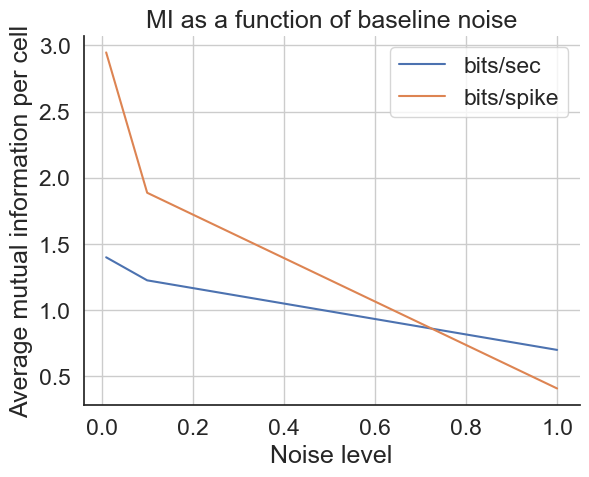

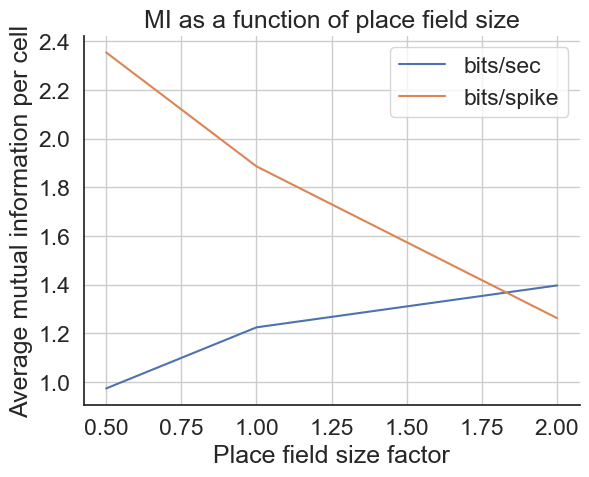

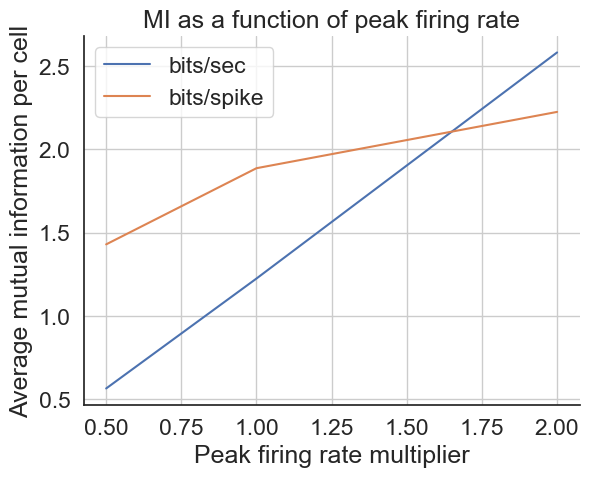

In [42]:
var_noise = df[(df['scale'] == 1.0) & (df['gain'] == 1.0)]
var_scale = df[(df['noise'] == 0.1) & (df['gain'] == 1.0)]
var_gain = df[(df['noise'] == 0.1) & (df['scale'] == 1.0)]


plt.figure()
plt.plot(var_noise['noise'], var_noise['MI_bits_sec_mean'], label='bits/sec')
plt.plot(var_noise['noise'], var_noise['MI_bits_spike_mean'], label='bits/spike')
plt.title('MI as a function of baseline noise')
plt.xlabel('Noise level')
plt.ylabel('Average mutual information per cell')
plt.legend()
plt.grid()

plt.figure()
plt.plot(var_scale['scale'], var_scale['MI_bits_sec_mean'], label='bits/sec')
plt.plot(var_scale['scale'], var_scale['MI_bits_spike_mean'], label='bits/spike')
plt.title('MI as a function of place field size')
plt.xlabel('Place field size factor')
plt.ylabel('Average mutual information per cell')
plt.legend()
plt.grid()

plt.figure()
plt.plot(var_gain['gain'], var_gain['MI_bits_sec_mean'], label='bits/sec')
plt.plot(var_gain['gain'], var_gain['MI_bits_spike_mean'], label='bits/spike')
plt.title('MI as a function of peak firing rate')
plt.xlabel('Peak firing rate multiplier')
plt.ylabel('Average mutual information per cell')
plt.legend()
plt.grid()

For increasing baseline noise both definitions of MI behave similarly: 
- Each decreases as noise level increases, this is to be expected; As previously observed increasing baseline noise level increases overlap and makes place field boundaries less obvious to define. Therefore it should follow that less information can be derived from the firing rate maps of individual cells on average
- As noise level increases firing rates and patterns (i.e. collections of spikes) in time likely become more useful for inferring spatial information/inferring position from cell activity than singular spikes. Therefore as noise increases the MI definition based on bits/spike estimates more information at low noise but the bits/second definition overtakes it as one needs to start considering ensembles of spikes instead of singular spikes to infer position from activity at higher noise levels.

For increasing place field size the definitions behave in an opposite manner although the bits/second definition appears less affected by the variation of this parameter:
- The bits/spike definition decreases its estimated info with place field size whereas the other definition increases. 
- The decreasing trend in the bits per spike definition can be explained by the fact that small place field size means that two adjecent cells become more likely to not overlap at all therefore, on average, for most cells, a spatial position might be directly derived from a single spike. This obviously becomes less true as place fields increase in size.
- The estimate of the bits per second defintion increases because once again, as place fields are broader x-positions are increasingly less obvious to infer. meaning that more spikes must be collected and patterns in time analyzed, before positions can be accurately guessed.

For increasing peak firing rate both definitions once again behave similarly:
- Both increase with increasing peak firing rate; this makes sense because due to the Gaussian shape of the firing rate distributions, cells fire non-linearly around their average rates. Therefore the signal to noise ratio of each cell increases if noise is kept constant while peak firing rate is raised. This makes every cells place field more distinguishable from baseline noise therefore making x-position easier to infer from both observing single spikes and patterns in time.

## Exercise 3 - working with real data
---
Load the data from `linear_track_data.pickle`. It contains neural recordings from a mouse running on a linear track.
- `x` contains the position of the animal
- `t` contains the corresponding times, in seconds
- `spikes` contains a list of lists. Each list contains the timestamps of the spikes emitted by a neuron.

A - Visualiaze the position a s a function of time. Plot the spike of a selected cell in space.

B - Calculate the firing rate maps for all the cells, and plot them sorted by increasing peak positon.

C - Calculate the spatial information for each cell, and plot the distribution. Plot the firing rate maps of the 5 cells with lower spatial information, and the firing rate maps of the 5 cells with higher spatial information. Comment on the differences.

In [61]:
#import data
with open('data/linear_track_data.pickle', 'rb') as handle:
    data = pickle.load(handle)

x = data['x']
t = data['t']
spikes = data['spikes']
n_cells = len(spikes)
fps = 1 / np.median(np.diff(t)) # Not known whether time axis is evenly spaced
track_length = np.max(x)

C:\Users\Jords\AppData\Local\Temp\ipykernel_36288\1322265122.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(handle)


A - Visualiaze the position a s a function of time. Plot the spike of a selected cell in space.

In [ ]:
def plot_unit(i):
    plt.figure(figsize=(10,5))
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    plt.xlabel('Time (s)')
    plt.ylabel('position on track (cm)')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0));

interactive(children=(IntSlider(value=0, description='i', max=71), Output()), _dom_classes=('widget-interact',…

B - Calculate the firing rate maps for all the cells, and plot them sorted by increasing peak positon.

In [63]:
def plot_hists(binsize):
    spike_positions = [np.interp(s, t, x) for s in spikes]
    space_bins = np.arange(0., track_length, binsize)

    # we compute histograms for eaxh cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]

    # put them together into a matrix of floating point numbers (for plotting)
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)

    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps

    firing_rate_maps = spikes_hist / occupancy
    firing_rate_maps /= np.max(firing_rate_maps, axis=1, keepdims=True)
    plt.figure(figsize=(20,5))
    plt.subplot(1,2,1)
    plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, track_length, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar()
    plt.subplot(1,2,2)
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent = [0, track_length, 0, n_cells])
    plt.xlabel('location (cm)')
    plt.ylabel('cell #')
    plt.colorbar();

interact(plot_hists, binsize = widgets.IntSlider(min=1, max=200, value=1))

interactive(children=(IntSlider(value=1, description='binsize', max=200, min=1), Output()), _dom_classes=('wid…

<function __main__.plot_hists(binsize)>

C - Calculate the spatial information for each cell, and plot the distribution. Plot the firing rate maps of the 5 cells with lower spatial information, and the firing rate maps of the 5 cells with higher spatial information. Comment on the differences.